# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use them because regular linear models can give unrealistic outputs (like probabilities less than 0 or greater than 1). Activation functions fix this by keeping outputs in a reasonable range and letting us model more complex relationships.
2. Cross-entropy works well because it compares predicted probabilities to the true answers. It especially punishes the model when it’s confidently wrong, which helps it learn better.
3. True. It’s linear in how it combines the inputs, but the final output is passed through a function (sigmoid), which makes it nonlinear.
4. False. It’s made for classification. It gives probabilities, and we use those to decide the class.
5. No. They show the change in log-odds, not the actual probability. The effect on probability depends on where you are on the curve.
6. False. Even though the output is nonlinear, the model itself is still linear in the inputs. So we still need feature engineering if the relationship is complex.
7. False. It depends on the problem. Logistic regression is for classification, while linear regression is for predicting continuous values.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("data/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols].copy()
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [7]:
# Handling missing values

df = df.dropna().copy()

print("Remaining rows:", len(df))
print(df.isna().sum())

Remaining rows: 4424
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


I checked for missing values in the variables used in the analysis and removed rows with missing data.

In [8]:
# Create binary dropout target
df["dropout_binary"] = (df["Target"] == "Dropout").astype(int)

df[["Target", "dropout_binary"]].head()

,Target,dropout_binary
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0


In [9]:
# Define X and y for the binary logistic regression
X_bin = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y_bin = df["dropout_binary"]

In [10]:
# Fit logistic regression
logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_bin, y_bin)

logit_coef_df = pd.DataFrame({
    "Feature": X_bin.columns,
    "Coefficient": logit_model.coef_[0]
})

logit_coef_df

,Feature,Coefficient
0,Debtor,0.530625
1,Tuition fees up to date,-2.556542
2,Scholarship holder,-1.227442
3,Age at enrollment,0.049925


Debtor and Age at enrollment predict a higher dropout probability, and Tuition fees up to date and scholarship holder predict a lower dropout probability. Yes, being up to date on tuition seems to reduce dropout probability. 

In [12]:
# Compute predicted dropout probabilities
df["logit_pred_prob"] = logit_model.predict_proba(X_bin)[:, 1]
df[["Age at enrollment", "Tuition fees up to date", "logit_pred_prob"]].head()

,Age at enrollment,Tuition fees up to date,logit_pred_prob
0,20,1,0.254958
1,19,0,0.807567
2,19,0,0.807567
3,20,1,0.254958
4,45,1,0.543836


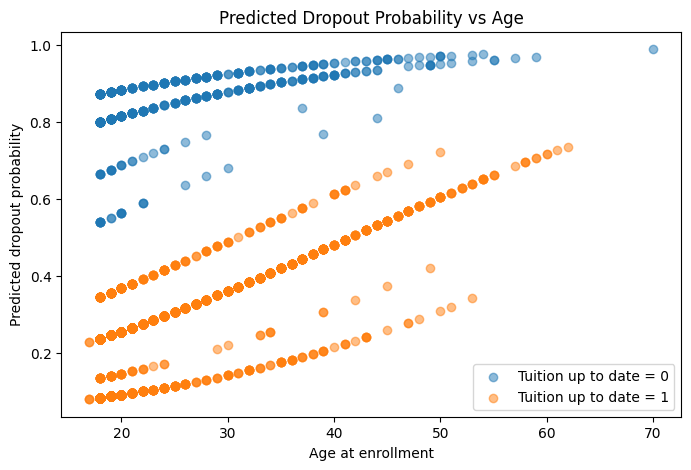

In [13]:
plt.figure(figsize=(8, 5))

for tuition_value in [0, 1]:
    subset = df[df["Tuition fees up to date"] == tuition_value]
    plt.scatter(
        subset["Age at enrollment"],
        subset["logit_pred_prob"],
        alpha=0.5,
        label=f"Tuition up to date = {tuition_value}"
    )

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted Dropout Probability vs Age")
plt.legend()
plt.show()

In [14]:
X_tuition_0 = X_bin.copy()
X_tuition_1 = X_bin.copy()

X_tuition_0["Tuition fees up to date"] = 0
X_tuition_1["Tuition fees up to date"] = 1

prob_if_0 = logit_model.predict_proba(X_tuition_0)[:, 1]
prob_if_1 = logit_model.predict_proba(X_tuition_1)[:, 1]

tuition_effect = prob_if_1 - prob_if_0

print("Average change in predicted dropout probability when tuition is up to date:")
print(tuition_effect.mean())

Average change in predicted dropout probability when tuition is up to date:
-0.51618197411964


In [15]:
df["tuition_effect_on_dropout_prob"] = tuition_effect

age_effect_summary = df.groupby("Age at enrollment")["tuition_effect_on_dropout_prob"].mean().reset_index()
age_effect_summary.head()

,Age at enrollment,tuition_effect_on_dropout_prob
0,17,-0.493953
1,18,-0.525951
2,19,-0.529255
3,20,-0.532669
4,21,-0.535541


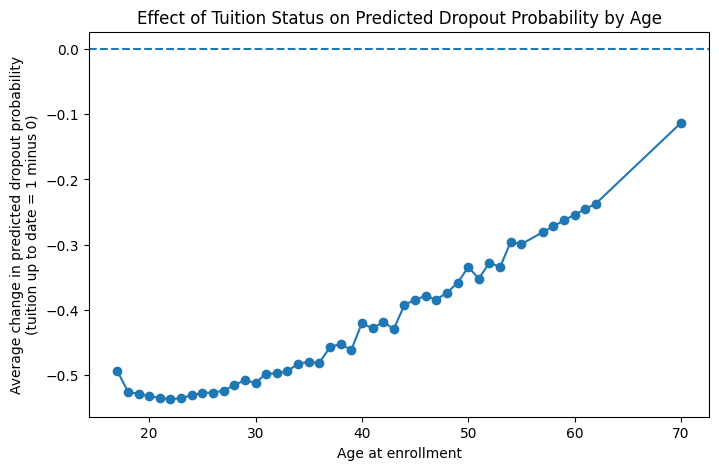

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(
    age_effect_summary["Age at enrollment"],
    age_effect_summary["tuition_effect_on_dropout_prob"],
    marker="o"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Age at enrollment")
plt.ylabel("Average change in predicted dropout probability\n(tuition up to date = 1 minus 0)")
plt.title("Effect of Tuition Status on Predicted Dropout Probability by Age")
plt.show()

From the plot, being up to date on tuition reduces dropout probability the most at younger ages, specifically around 20-21. 

In [17]:
# Confusion matrix and accuracy
y_pred_logit = logit_model.predict(X_bin)

cm_logit = confusion_matrix(y_bin, y_pred_logit)
acc_logit = accuracy_score(y_bin, y_pred_logit)

print("Confusion Matrix:")
print(cm_logit)

print("\nAccuracy:", acc_logit)

Confusion Matrix:
[[2841  162]
 [ 891  530]]

Accuracy: 0.7619801084990958


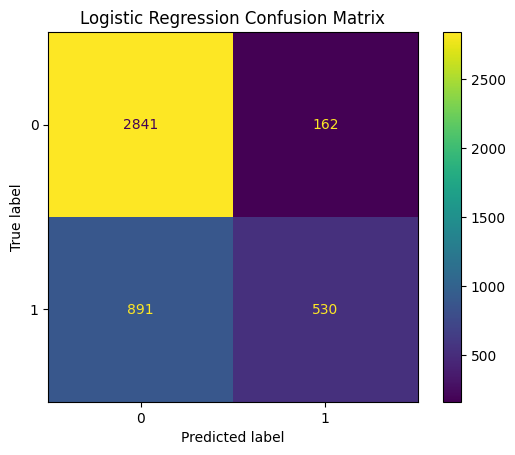

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logit)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [19]:
# Fit a linear model with the same variables
linear_model = LinearRegression()
linear_model.fit(X_bin, y_bin)

df["linear_pred_prob"] = linear_model.predict(X_bin)

df[["logit_pred_prob", "linear_pred_prob"]].head()

,logit_pred_prob,linear_pred_prob
0,0.254958,0.263253
1,0.807567,0.765932
2,0.807567,0.765932
3,0.254958,0.263253
4,0.543836,0.500429


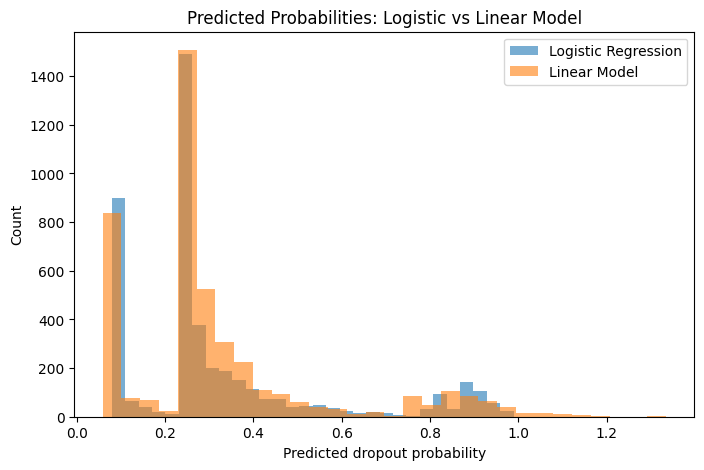

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["logit_pred_prob"], bins=30, alpha=0.6, label="Logistic Regression")
plt.hist(df["linear_pred_prob"], bins=30, alpha=0.6, label="Linear Model")
plt.xlabel("Predicted dropout probability")
plt.ylabel("Count")
plt.title("Predicted Probabilities: Logistic vs Linear Model")
plt.legend()
plt.show()

In [23]:
# Comparing performance of linear model using 0.5 threshold
y_pred_linear = (df["linear_pred_prob"] >= 0.5).astype(int)

cm_linear = confusion_matrix(y_bin, y_pred_linear)
acc_linear = accuracy_score(y_bin, y_pred_linear)

print("Linear Model Confusion Matrix:")
print(cm_linear)

print("\nLinear Model Accuracy:", acc_linear)

print("\nLogistic Regression Accuracy:", acc_logit)

Linear Model Confusion Matrix:
[[2870  133]
 [ 914  507]]

Linear Model Accuracy: 0.7633363471971067

Logistic Regression Accuracy: 0.7619801084990958


In [24]:
at_risk_students = df.sort_values("logit_pred_prob", ascending=False).copy()

at_risk_students[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target",
    "logit_pred_prob"
]].head(20)

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,logit_pred_prob
689,1,0,0,70,0,Dropout,0.989133
2876,1,0,0,54,0,Dropout,0.976161
717,1,0,0,53,3,Dropout,0.974971
1887,1,0,0,51,0,Dropout,0.972415
3472,1,0,0,50,0,Dropout,0.971044
678,1,0,0,50,1,Dropout,0.971044
709,1,0,0,50,0,Dropout,0.971044
3526,1,0,0,49,5,Dropout,0.969607
3281,0,0,0,59,12,Dropout,0.968668
4260,1,0,0,48,0,Dropout,0.968100


From the results, the students most at risk of dropping out are often not up to date on tuition, frequently have outstanding debt, do not have scholarships, and have low numbers of approved curricular units in the first semester. Many of these high-risk students are also older at enrollment. These characteirstics are all associated with higher dropout probability.

To help reduce dropout risk, interventions could focus on financial support, such as helping students stay current on tuition or providing scholarships. Academic support could also be important especially for students with few approved courses through tutoring or advising. Additionally, targeted outreach to older or financially struggling students may help address challenges early and improve retention.

In [25]:
# Multinomial logistic regression features and target
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]

In [26]:
# Fit multinomial logistic regression
multi_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)

multi_model.fit(X_multi, y_multi)

/opt/anaconda3/envs/BME2315/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='multinomial')

In [27]:
# Hard classification and confusion matrix
y_multi_pred = multi_model.predict(X_multi)

cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=multi_model.classes_)
acc_multi = accuracy_score(y_multi, y_multi_pred)

print("Classes:", multi_model.classes_)
print("\nConfusion Matrix:")
print(cm_multi)
print("\nAccuracy:", acc_multi)


Classes: ['Dropout' 'Enrolled' 'Graduate']

Confusion Matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

Accuracy: 0.7045660036166366


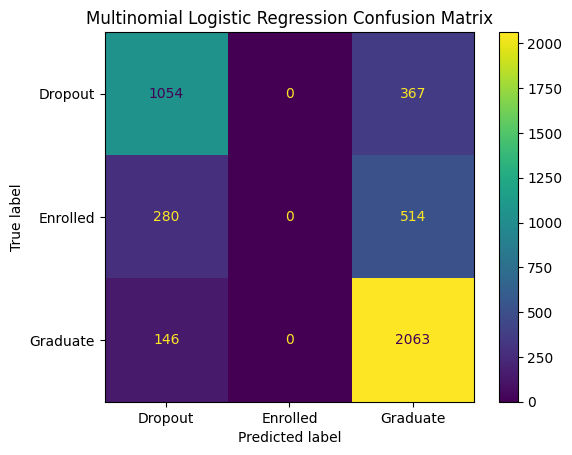

In [28]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=multi_model.classes_
)
disp.plot()
plt.title("Multinomial Logistic Regression Confusion Matrix")
plt.show()

The model achieves about 70.5% accuracy and performs best at predicting the Graduate class with many correct classifications. It also does reasonably well for Dropout but misclassifies some as graduates.

However, it performs very poorly for the Enrolled class with zero correct predictions, meaning it cannot distinguish this group. Overall, the model tends to favor predicting Graduate, likely due to class imbalance or limited feature information.

In [29]:
# Predicted probabilities for each class
multi_prob_df = pd.DataFrame(
    multi_model.predict_proba(X_multi),
    columns=multi_model.classes_
)

multi_prob_df.head()

,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104


In [30]:
print("Classes predicted by hard classification:")
print(pd.Series(y_multi_pred).value_counts())

print("\nActual classes:")
print(y_multi.value_counts())

Classes predicted by hard classification:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

Actual classes:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [31]:
print("Average predicted probability for each class:")
print(multi_prob_df.mean())

Average predicted probability for each class:
Dropout     0.321223
Enrolled    0.179474
Graduate    0.499303
dtype: float64


The hard classification does not predict every class since it never predicts the Enrolled category. However, the predicted probabilities do include all classes as each observation has nonzero probabilities for Dropout, Enrolled, and Graduate. This shows that while the model recognizes all classes, the hard predictions favor the most likely ones and ignore less likely classes like Enrolled.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [33]:
df = pd.read_csv("data/cirrhosis.csv")
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [34]:
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols].copy()

df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [35]:
# Check for missing values
print(df.isna().sum())

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [36]:
# Handle missing values

df = df.dropna().copy()

print("Remaining rows:", len(df))
print(df.isna().sum())

Remaining rows: 312
Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64


In [37]:
# Create binary survival outcome
df["survival_binary"] = df["Status"].isin(["C", "CL"]).astype(int)

df[["Status", "survival_binary"]].head()

,Status,survival_binary
0,D,0
1,C,1
2,D,0
3,D,0
4,CL,1


In [38]:
# encode Edema and Drug
X = pd.get_dummies(
    df[["Edema", "Drug", "Bilirubin"]],
    drop_first=True
)

X.head()

,Bilirubin,Edema_S,Edema_Y,Drug_Placebo
0,14.5,False,True,False
1,1.1,False,False,False
2,1.4,True,False,False
3,1.8,True,False,False
4,3.4,False,False,True


In [40]:
# Define target
y = df["survival_binary"]

In [41]:
# Fit logistic regression
logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X, y)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logit_model.coef_[0]
})

coef_df

,Feature,Coefficient
0,Bilirubin,-0.351424
1,Edema_S,-0.450677
2,Edema_Y,-1.611049
3,Drug_Placebo,0.231225


In [42]:
coef_df["Direction"] = np.where(
    coef_df["Coefficient"] > 0,
    "Higher survival probability",
    "Lower survival probability"
)

coef_df

,Feature,Coefficient,Direction
0,Bilirubin,-0.351424,Lower survival probability
1,Edema_S,-0.450677,Lower survival probability
2,Edema_Y,-1.611049,Lower survival probability
3,Drug_Placebo,0.231225,Higher survival probability


In [43]:
df["logit_pred_survival"] = logit_model.predict_proba(X)[:, 1]

df[["Bilirubin", "Drug", "logit_pred_survival"]].head()

,Bilirubin,Drug,logit_pred_survival
0,14.5,D-penicillamine,0.004836
1,1.1,D-penicillamine,0.729732
2,1.4,D-penicillamine,0.607582
3,1.8,D-penicillamine,0.573608
4,3.4,Placebo,0.602576


Higher bilirubin levels are associated with a lower survival probability, indicating worse outcomes as bilirubin increases. Patients with edema (both S and Y) also have lower survival probabilities, with severe edema (Y) having a stronger negative effect.

Comparing the drug groups, patients on D-penicillamine tend to have lower predicted survival probabilities than those on placebo at similar bilirubin levels. This suggests that the drug does not improve survival probability in this model and may be associated with worse outcomes.

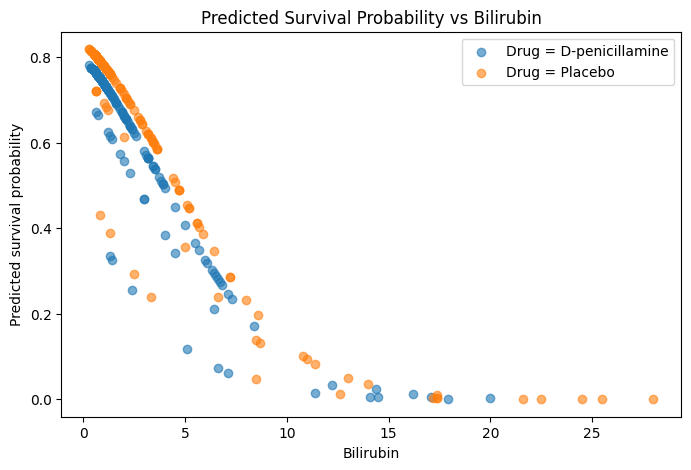

In [44]:
plt.figure(figsize=(8, 5))

for drug_name in df["Drug"].unique():
    subset = df[df["Drug"] == drug_name]
    plt.scatter(
        subset["Bilirubin"],
        subset["logit_pred_survival"],
        alpha=0.6,
        label=f"Drug = {drug_name}"
    )

plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted Survival Probability vs Bilirubin")
plt.legend()
plt.show()

In [45]:
# Check actual dummy column names first
print(X.columns)

Index(['Bilirubin', 'Edema_S', 'Edema_Y', 'Drug_Placebo'], dtype='object')


In [46]:
X_drug0 = X.copy()
X_drug1 = X.copy()

drug_dummy_col = [col for col in X.columns if col.startswith("Drug_")][0]



X_drug0[drug_dummy_col] = 0
X_drug1[drug_dummy_col] = 1

prob0 = logit_model.predict_proba(X_drug0)[:, 1]
prob1 = logit_model.predict_proba(X_drug1)[:, 1]

drug_effect = prob1 - prob0

print("Drug dummy column used:", drug_dummy_col)
print("Average change in predicted survival probability when dummy changes from 0 to 1:")
print(drug_effect.mean())

Drug dummy column used: Drug_Placebo
Average change in predicted survival probability when dummy changes from 0 to 1:
0.042426639431640226


In [47]:
df["drug_effect_on_survival"] = drug_effect

bilirubin_effect_summary = df.groupby("Bilirubin")["drug_effect_on_survival"].mean().reset_index()
bilirubin_effect_summary.head()

,Bilirubin,drug_effect_on_survival
0,0.3,0.036917
1,0.4,0.037696
2,0.5,0.038476
3,0.6,0.040989
4,0.7,0.040506


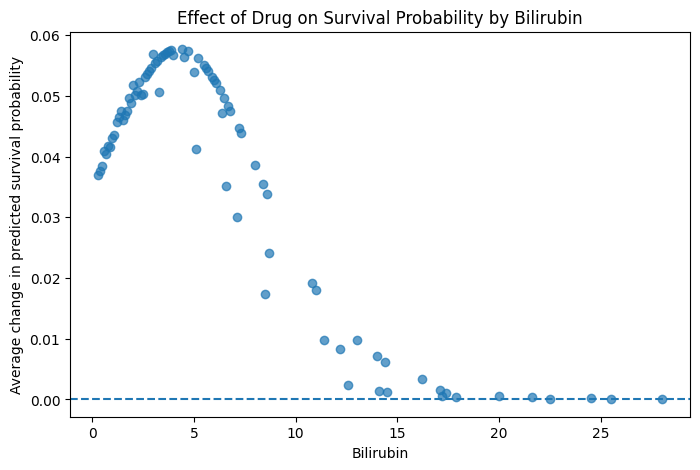

In [48]:
plt.figure(figsize=(8, 5))
plt.scatter(
    bilirubin_effect_summary["Bilirubin"],
    bilirubin_effect_summary["drug_effect_on_survival"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.xlabel("Bilirubin")
plt.ylabel("Average change in predicted survival probability")
plt.title("Effect of Drug on Survival Probability by Bilirubin")
plt.show()

From the plots, the drug appears to increase survival probability most at low to moderate bilirubin levels (roughly between 0 and 7), where the gap between the two groups is largest. As bilirubin increases beyond this range, the effect of the drug becomes much smaller and approaches zero.

On average, switching from the drug to placebo increases predicted survival probability by about 0.042 (4.2 percentage points). This suggests that, overall, the drug does not improve survival and may slightly reduce it compared to placebo.

In [49]:
# Hard predictions, confusion matrix, accuracy
y_pred_logit = logit_model.predict(X)

cm_logit = confusion_matrix(y, y_pred_logit)
acc_logit = accuracy_score(y, y_pred_logit)

print("Confusion Matrix:")
print(cm_logit)

print("\nAccuracy:", acc_logit)

Confusion Matrix:
[[ 59  66]
 [ 16 171]]

Accuracy: 0.7371794871794872


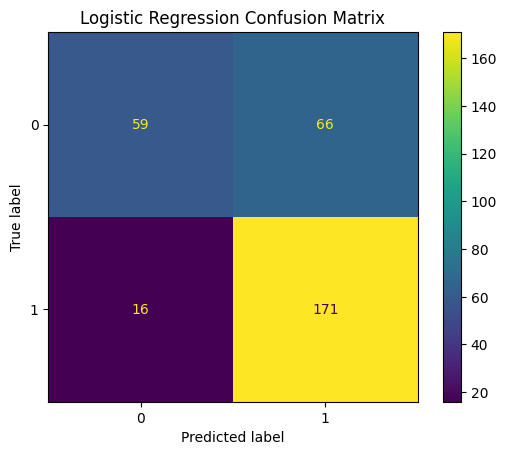

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logit)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [51]:
# Linear model
linear_model = LinearRegression()
linear_model.fit(X, y)

df["linear_pred_survival"] = linear_model.predict(X)

df[["logit_pred_survival", "linear_pred_survival"]].head()

,logit_pred_survival,linear_pred_survival
0,0.004836,-0.179839
1,0.729732,0.691974
2,0.607582,0.561373
3,0.573608,0.545746
4,0.602576,0.652758


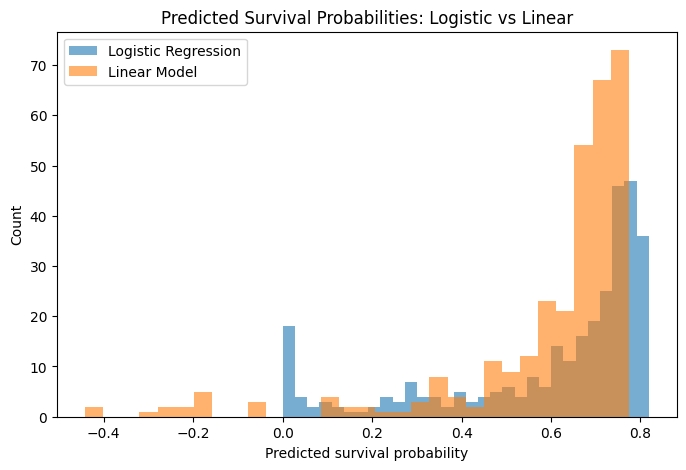

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df["logit_pred_survival"], bins=30, alpha=0.6, label="Logistic Regression")
plt.hist(df["linear_pred_survival"], bins=30, alpha=0.6, label="Linear Model")
plt.xlabel("Predicted survival probability")
plt.ylabel("Count")
plt.title("Predicted Survival Probabilities: Logistic vs Linear")
plt.legend()
plt.show()

In [53]:
y_pred_linear = (df["linear_pred_survival"] >= 0.5).astype(int)

cm_linear = confusion_matrix(y, y_pred_linear)
acc_linear = accuracy_score(y, y_pred_linear)

print("Linear Model Confusion Matrix:")
print(cm_linear)

print("\nLinear Model Accuracy:", acc_linear)

print("\nLogistic Regression Accuracy:", acc_logit)

Linear Model Confusion Matrix:
[[ 47  78]
 [  9 178]]

Linear Model Accuracy: 0.7211538461538461

Logistic Regression Accuracy: 0.7371794871794872


The logistic regression model performs slightly better than the linear model, with a higher accuracy. Additionally, logistic regression produces predicted probabilities that are properly bounded between 0 and 1, while the linear model can produce unrealistic values outside this range like negative probabilities. Overall, logistic regression is more appropriate for this classification problem because it provides more interpretable and valid probability estimates.

In [54]:
# Multiclass logistic regression for stage
X_stage = pd.get_dummies(
    df[["Edema", "Bilirubin"]],
    drop_first=True
)

y_stage = df["Stage"]

In [55]:
stage_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)

stage_model.fit(X_stage, y_stage)

/opt/anaconda3/envs/BME2315/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='multinomial')

In [56]:
# Hard classification and confusion matrix for Stage
y_stage_pred = stage_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_stage_pred, labels=stage_model.classes_)
acc_stage = accuracy_score(y_stage, y_stage_pred)

print("Classes:", stage_model.classes_)
print("\nConfusion Matrix:")
print(cm_stage)
print("\nAccuracy:", acc_stage)

Classes: [1. 2. 3. 4.]

Confusion Matrix:
[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]

Accuracy: 0.4326923076923077


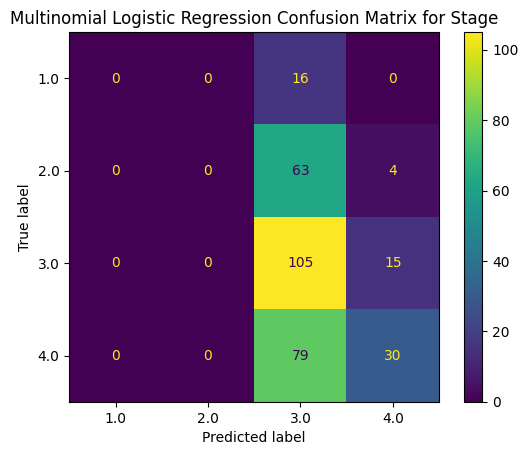

In [57]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_stage,
    display_labels=stage_model.classes_
)
disp.plot()
plt.title("Multinomial Logistic Regression Confusion Matrix for Stage")
plt.show()

The multinomial logistic regression model has relatively low accuracy, indicating limited predictive performance. From the confusion matrix, the model almost always predicts Stage 3, regardless of the true stage, and occasionally predicts Stage 4, but never predicts Stage 1 or Stage 2. This suggests the model is unable to distinguish between the different stages and is heavily biased toward the most common class (Stage 3). Overall, the model struggles to capture meaningful differences between stages using the given features.

In [59]:
# Predicted probabilities for each Stage
stage_prob_df = pd.DataFrame(
    stage_model.predict_proba(X_stage),
    columns=stage_model.classes_
)

stage_prob_df.head()

,1.0,2.0,3.0,4.0
0,0.000013,0.032535,0.143611,0.823841
1,0.072394,0.251555,0.397520,0.278531
2,0.029263,0.181531,0.395694,0.393512
3,0.023272,0.176777,0.397217,0.402734
4,0.020204,0.224965,0.423342,0.331488


In [60]:
print("Classes predicted by hard classification:")
print(pd.Series(y_stage_pred).value_counts().sort_index())

print("\nActual classes:")
print(y_stage.value_counts().sort_index())

Classes predicted by hard classification:
3.0    263
4.0     49
Name: count, dtype: int64

Actual classes:
Stage
1.0     16
2.0     67
3.0    120
4.0    109
Name: count, dtype: int64


In [61]:
print("Average predicted probability for each class:")
print(stage_prob_df.mean())

Average predicted probability for each class:
1.0    0.051252
2.0    0.214685
3.0    0.384666
4.0    0.349397
dtype: float64


In [62]:
results_stage = df[["Stage"]].copy()
results_stage["Predicted_Stage"] = y_stage_pred

for col in stage_model.classes_:
    results_stage[f"Prob_Stage_{col}"] = stage_prob_df[col]

results_stage.head(20)

,Stage,Predicted_Stage,Prob_Stage_1.0,Prob_Stage_2.0,Prob_Stage_3.0,Prob_Stage_4.0
0,4.0,4.0,0.000013,0.032535,0.143611,0.823841
1,3.0,3.0,0.072394,0.251555,0.397520,0.278531
2,4.0,3.0,0.029263,0.181531,0.395694,0.393512
3,4.0,4.0,0.023272,0.176777,0.397217,0.402734
4,3.0,3.0,0.020204,0.224965,0.423342,0.331488
5,3.0,3.0,0.084886,0.253397,0.391412,0.270305
6,3.0,3.0,0.076359,0.252233,0.395575,0.275833
7,3.0,3.0,0.110046,0.255032,0.379260,0.255662
8,2.0,3.0,0.022637,0.227782,0.422181,0.327400
9,4.0,4.0,0.000042,0.040292,0.153955,0.805712


The hard classification does not predict every class, as it only predicts Stage 3 and Stage 4, and completely misses Stage 1 and Stage 2. However, the predicted probabilities do include all classes, since each observation has nonzero probabilities for Stages 1 through 4. This shows that while the model recognizes all classes, the hard predictions favor the most likely ones and ignore less likely stages.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

1. 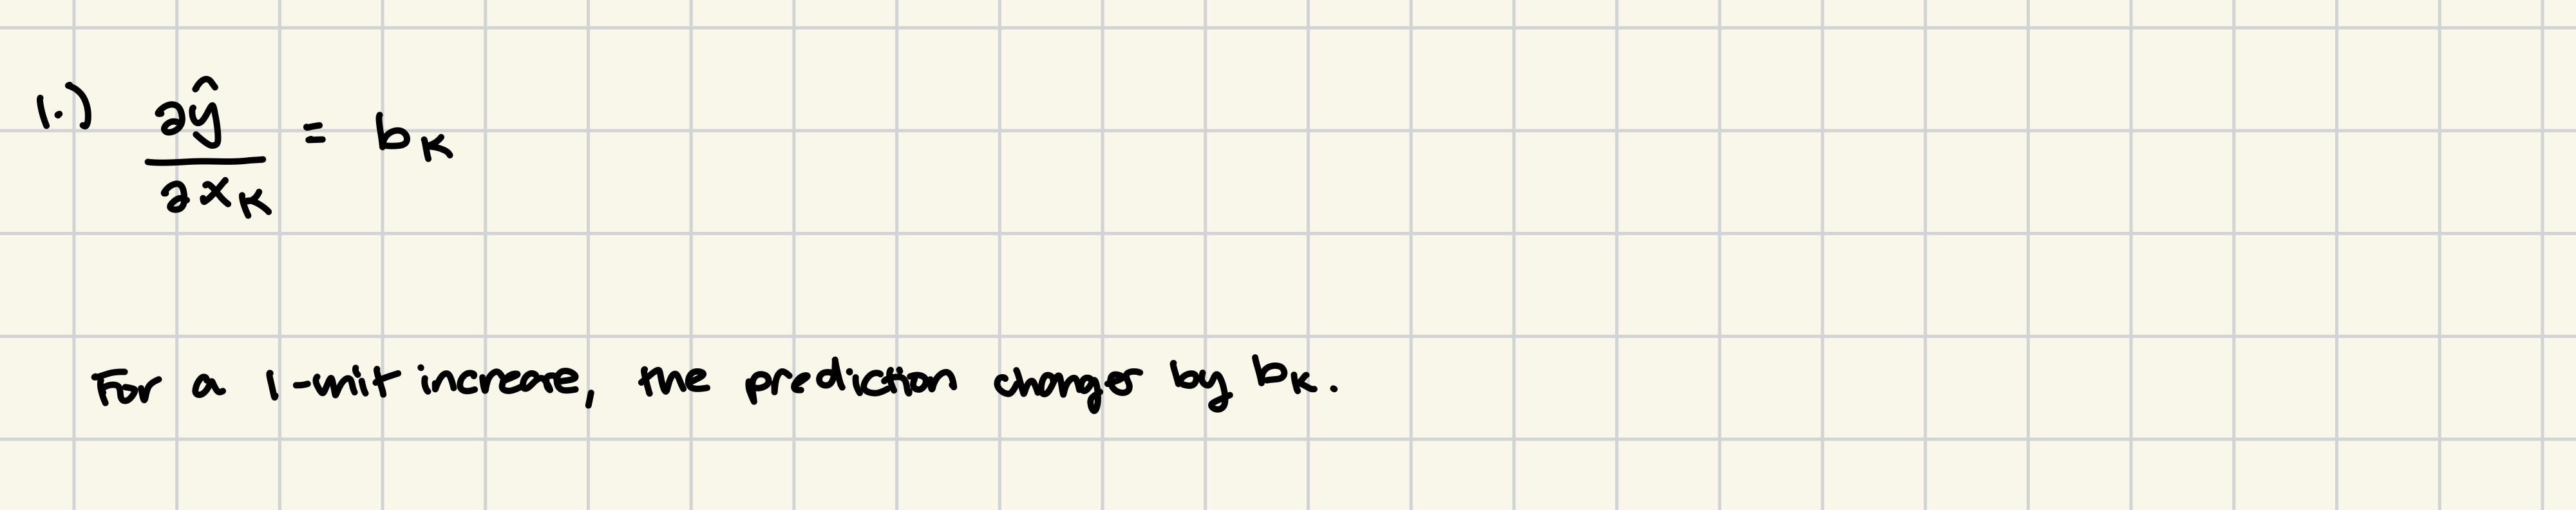
2. 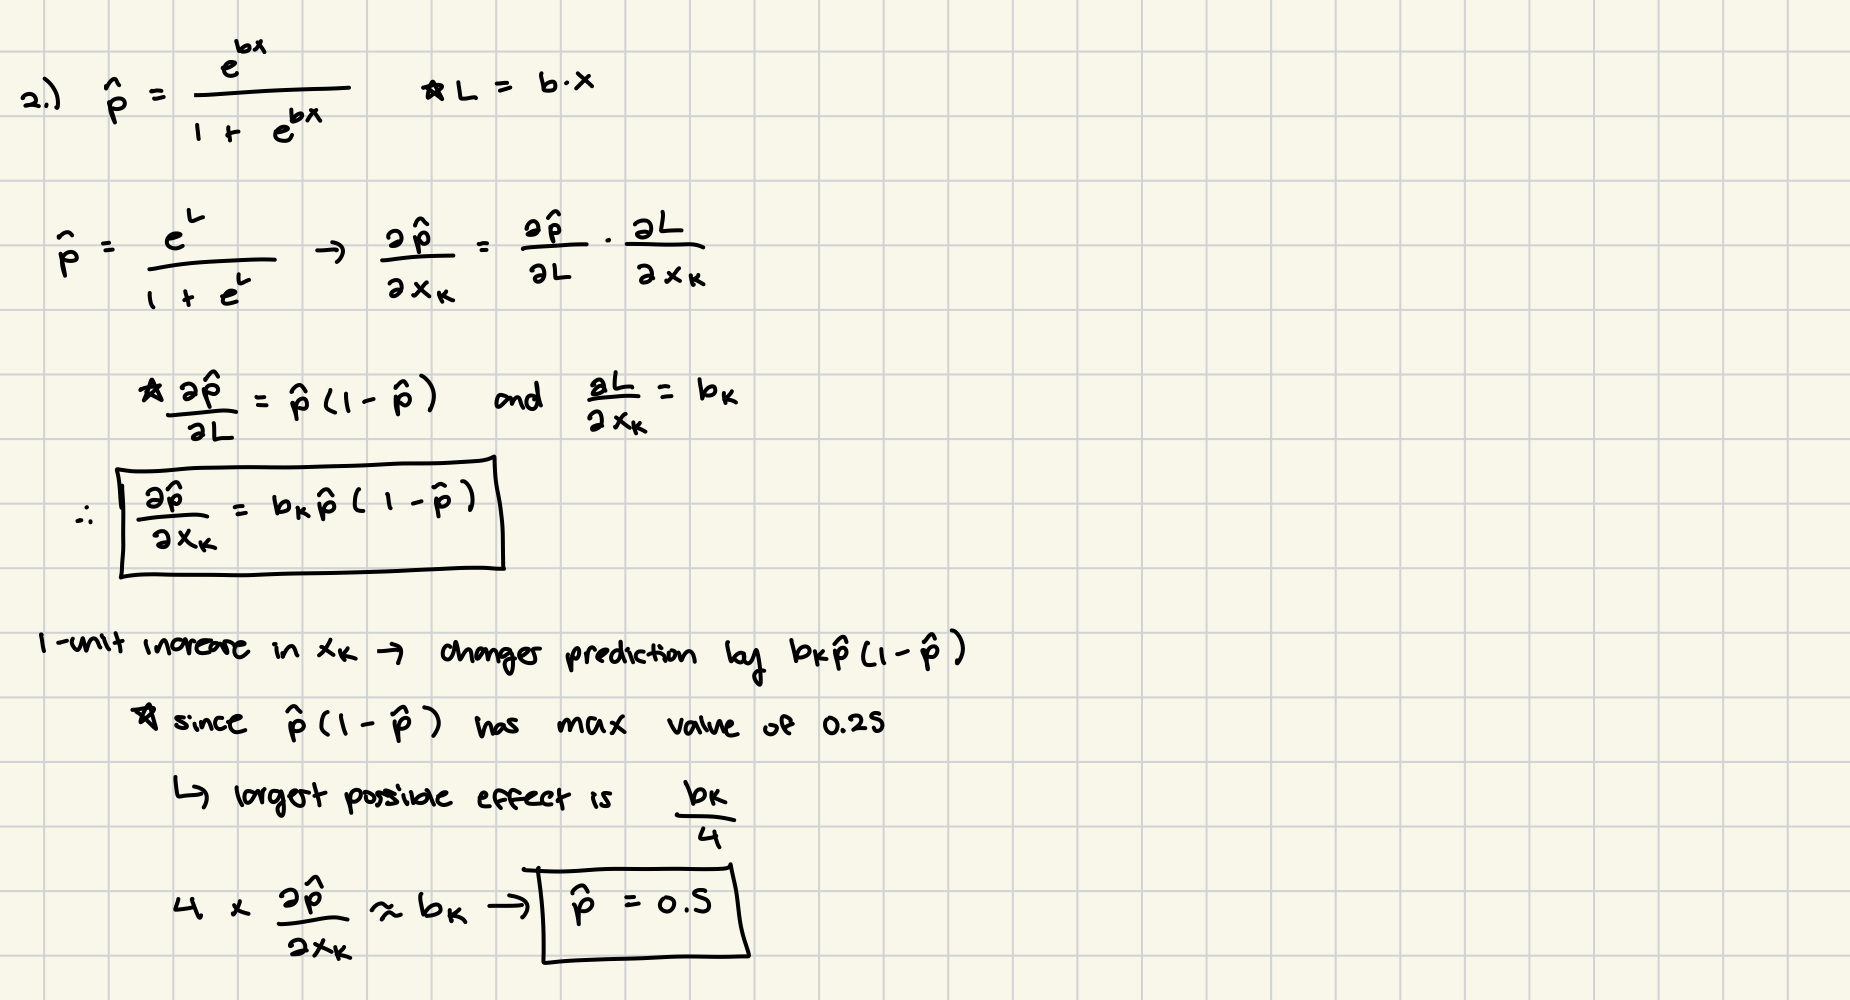
3. 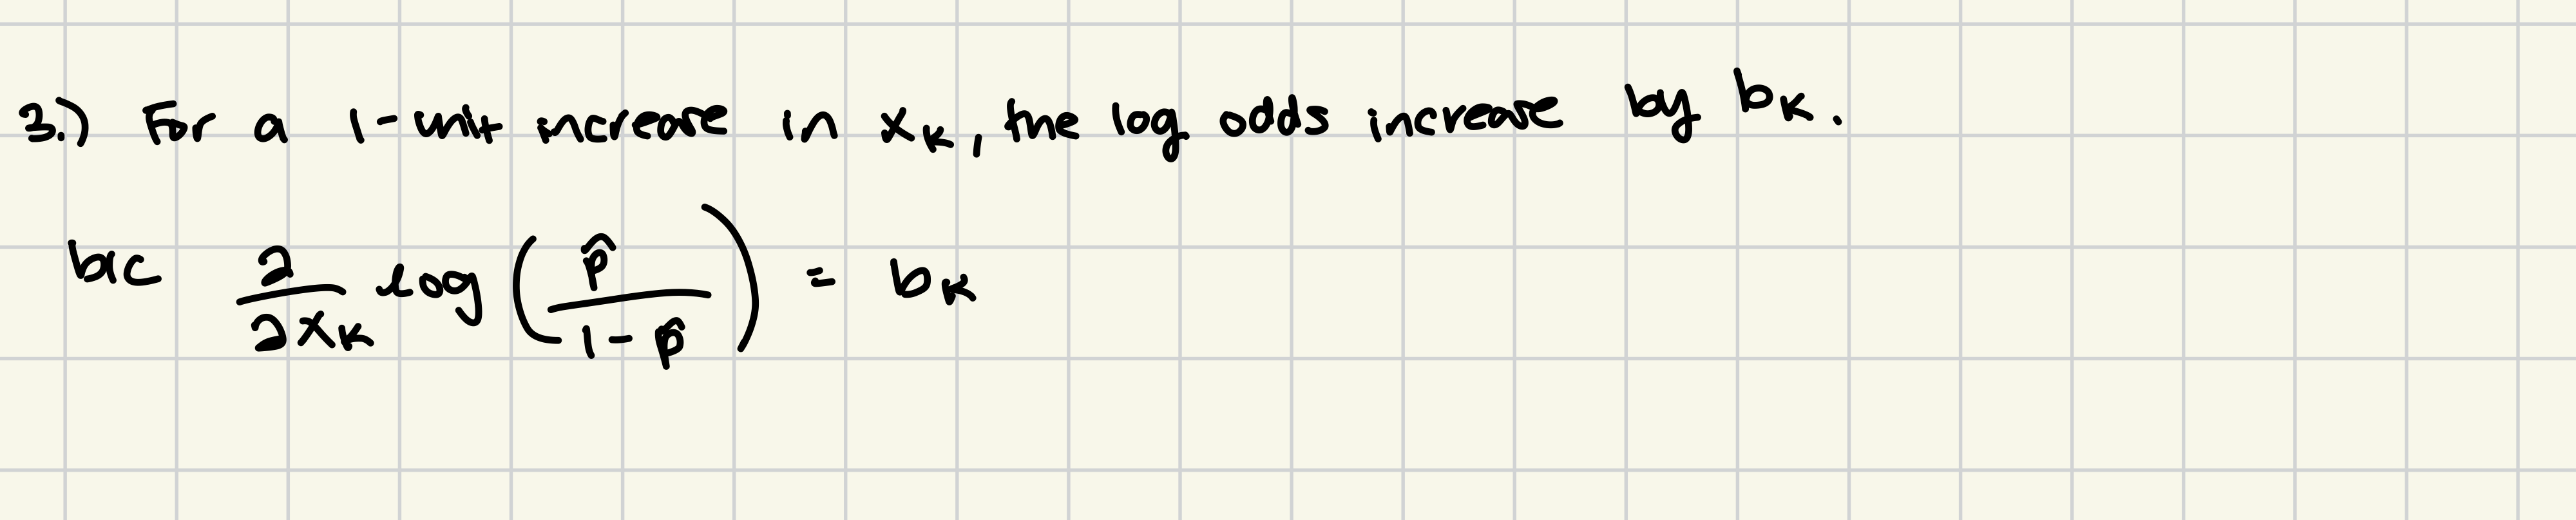